In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from plotnine import *

In [3]:
custom_colors = [
    "#1D2951",  # Space Cadet (dark blue)
    "#FFD166",  # Warm Yellow
    "#4BA3C3",  # Sky Blue
    "#F25C54",  # Coral Red
    "#007C91",  # Deep Teal
    "#EF798A",  # Dusty Rose
    "#6DCDB8",  # Mint Green
    "#FF9F1C",  # Vivid Orange
    "#6B4C9A",  # Violet Indigo
    "#A4C400",  # Lime Green
    "#8E7DBE",  # Lavender Purple
    "#2E8B57",  # Sea Green
]

In [4]:
# Bug causes the problem that automatic coloring does not work anymore
# -> Create custom color palette

# Add large qualitative colormaps together
colors = (
    plt.cm.Paired.colors
    + plt.cm.Set1.colors
    + plt.cm.tab20.colors
    + plt.cm.Set2.colors
    + plt.cm.tab20b.colors
    + plt.cm.Set3.colors
    + plt.cm.tab20c.colors
)

custom_colors_xl = [plt.matplotlib.colors.to_hex(c) for c in colors]
custom_colors_xl = custom_colors + custom_colors_xl

len(custom_colors_xl)

113

In [5]:
figure_theme = theme_minimal() + theme(
    plot_background=element_rect(fill="#ffffff", color="#ffffff"),
    plot_tag=element_text(face="bold"),
    legend_title=element_text(size=11, face="plain"),
    axis_title=element_text(size=10, face="plain"),
    axis_text=element_text(size=9, face="plain"),
    text=element_text(family="DejaVu Sans"),
)

## Cells per Field of View

In [5]:
# Load data
data = pd.read_feather("data/pdata_cells_per_fov.feather")
data.head()

,group,dataset,value
0,10,liver1,705
1,10,liver2,897
2,11,liver1,787
3,11,liver2,669
4,12,liver1,925


In [6]:
# Preprocess data
data["dataset"] = data["dataset"].replace({"liver1": "Liver1", "liver2": "Liver2"})

# Order groups by descending order
data["group"] = data["group"].astype(int)
data["group"] = pd.Categorical(
    data["group"], categories=sorted(data["group"].unique(), reverse=True), ordered=True
)

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/#cells_per_fov.svg


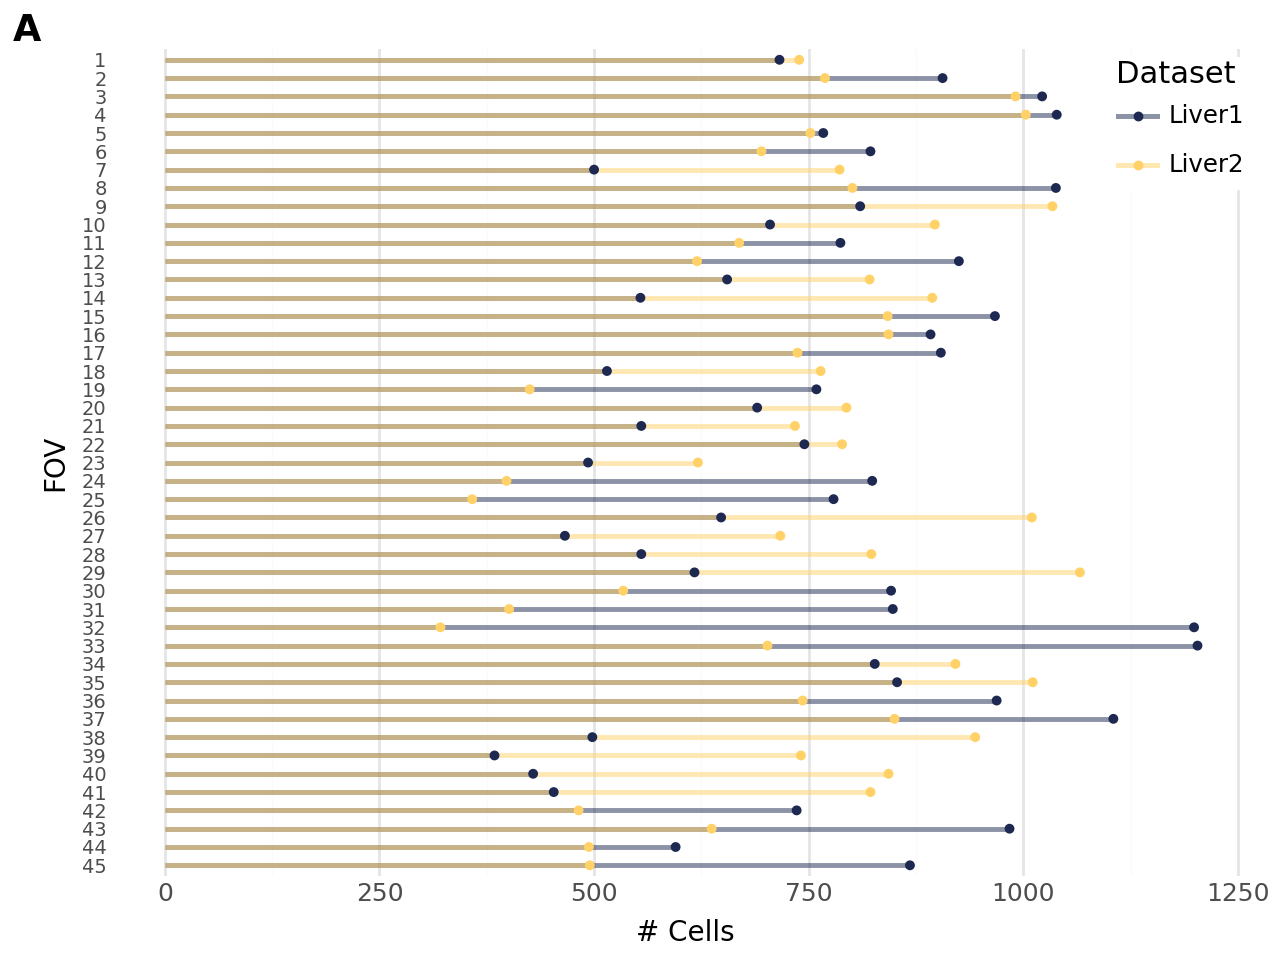

In [7]:
plot = (
    ggplot(data, aes(y="group", x="value", color="dataset"))
    + geom_segment(aes(x=0, xend="value", y="group", yend="group"), size=1, alpha=0.5)
    + geom_point(size=1)
    + scale_x_continuous(limits=(0, data["value"].max() + 10))
    + scale_y_discrete()
    + scale_color_manual(values={"Liver1": "#1D2951", "Liver2": "#FFD166"})
    + labs(tag="A", x="# Cells", y="FOV", color="Dataset")
    + figure_theme
    + theme(
        panel_grid_major_y=element_blank(),
        legend_position=(0.99, 0.99),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
        axis_text_y=element_text(size=7),
    )
)

plot.save("output/parts/#cells_per_fov.svg", dpi=300)
plot

## Count Distributions

In [8]:
# Load cell count distribution
data = pd.read_feather("data/pdata_counts_per_cell.feather")

data["dataset"] = data["dataset"].replace({"liver1": "Liver1", "liver2": "Liver2"})
data["disease_state"] = data["disease_state"].map(
    {
        "healthy": "Healthy",
        "steatosis": "Steatosis",
        "cirrhosis": "Cirrhosis",
        "aclf": "ACLF",
    }
)

data.head()

,value,dataset,disease_state
0,450.0,Liver1,Healthy
1,780.0,Liver1,Healthy
2,752.0,Liver1,Healthy
3,725.0,Liver1,Healthy
4,395.0,Liver1,Healthy


/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/density_sample_counts.svg


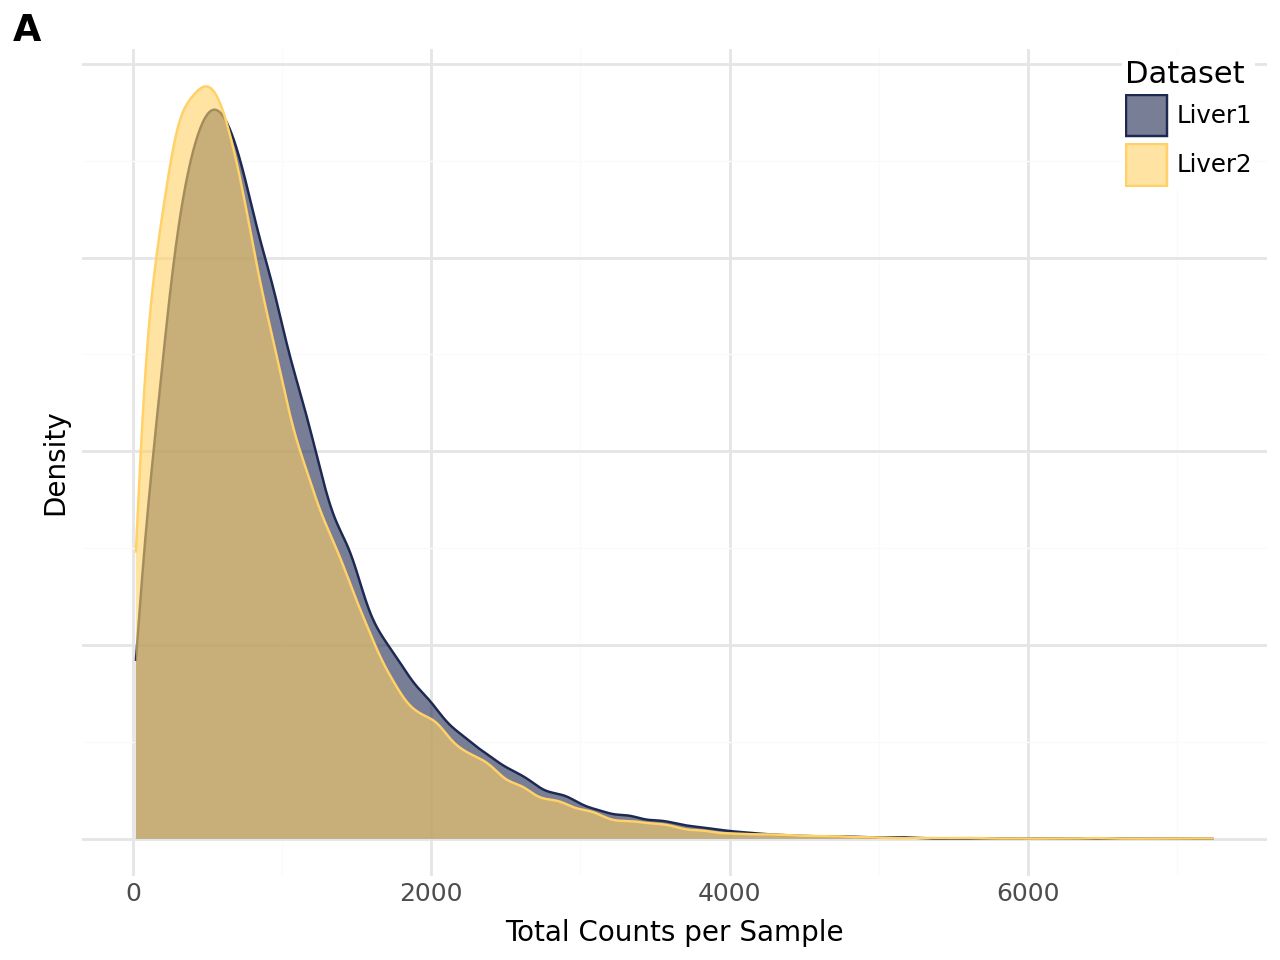

In [9]:
plot = (
    ggplot(data, aes(x="value", color="dataset", fill="dataset"))
    + geom_density(alpha=0.6)
    + scale_color_manual(custom_colors[:2])
    + scale_fill_manual(custom_colors[:2])
    + labs(
        tag="A",
        x="Total Counts per Sample",
        y="Density",
        color="Dataset",
        fill="Dataset",
    )
    + figure_theme
    + theme(
        axis_text_y=element_blank(),
        legend_position=(0.99, 0.99),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/density_sample_counts.svg", dpi=300)
plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/ecdf_sample_counts.svg


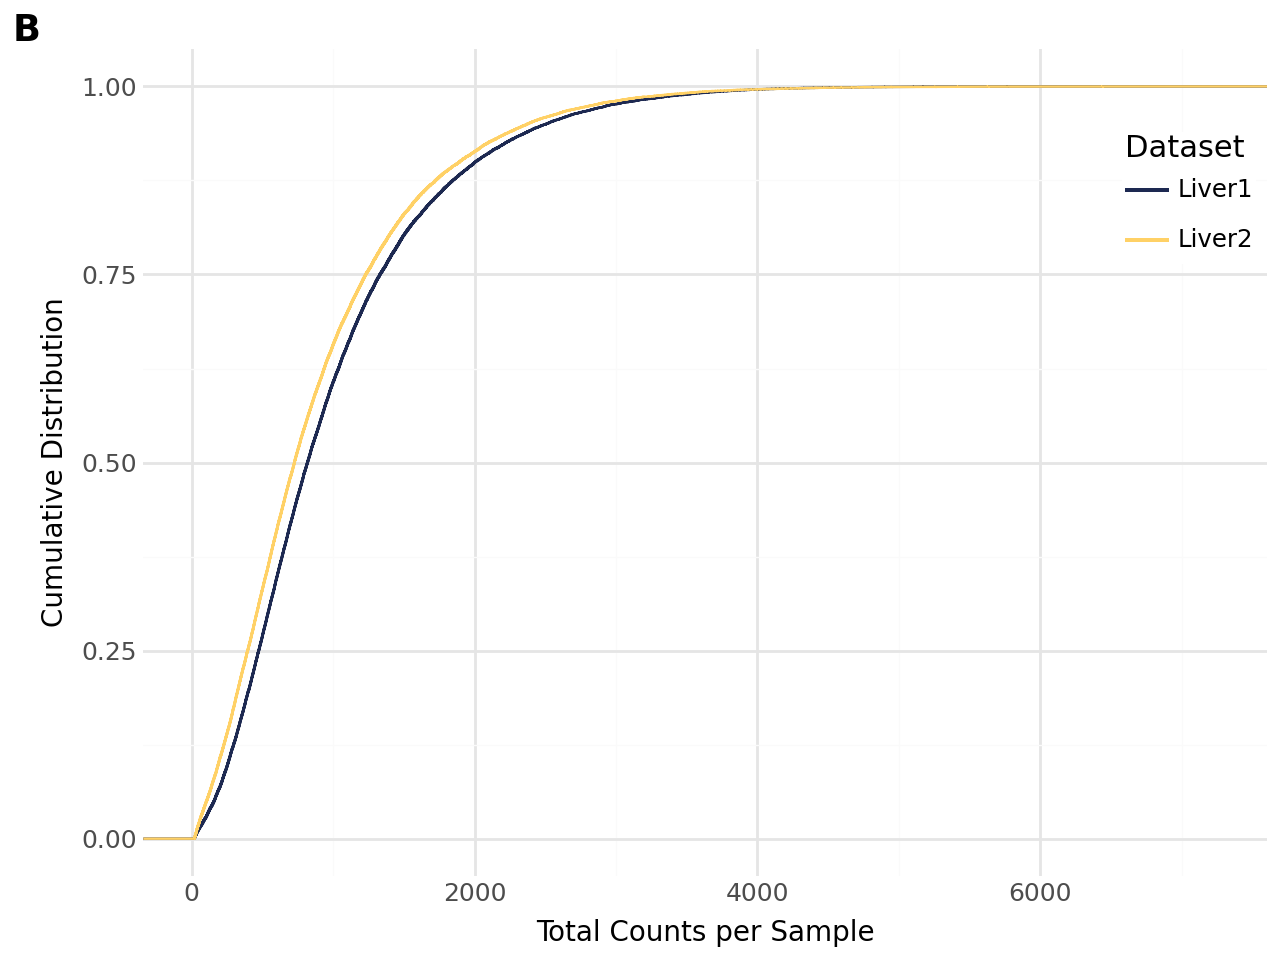

In [10]:
plot = (
    ggplot(data, aes(x="value", color="dataset"))
    + stat_ecdf(geom="step")
    + scale_color_manual(custom_colors[:2])
    + labs(
        tag="B",
        x="Total Counts per Sample",
        y="Cumulative Distribution",
        color="Dataset",
    )
    + figure_theme
    + theme(
        legend_position=(0.99, 0.90),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/ecdf_sample_counts.svg", dpi=300)
plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/density_condition_counts.svg


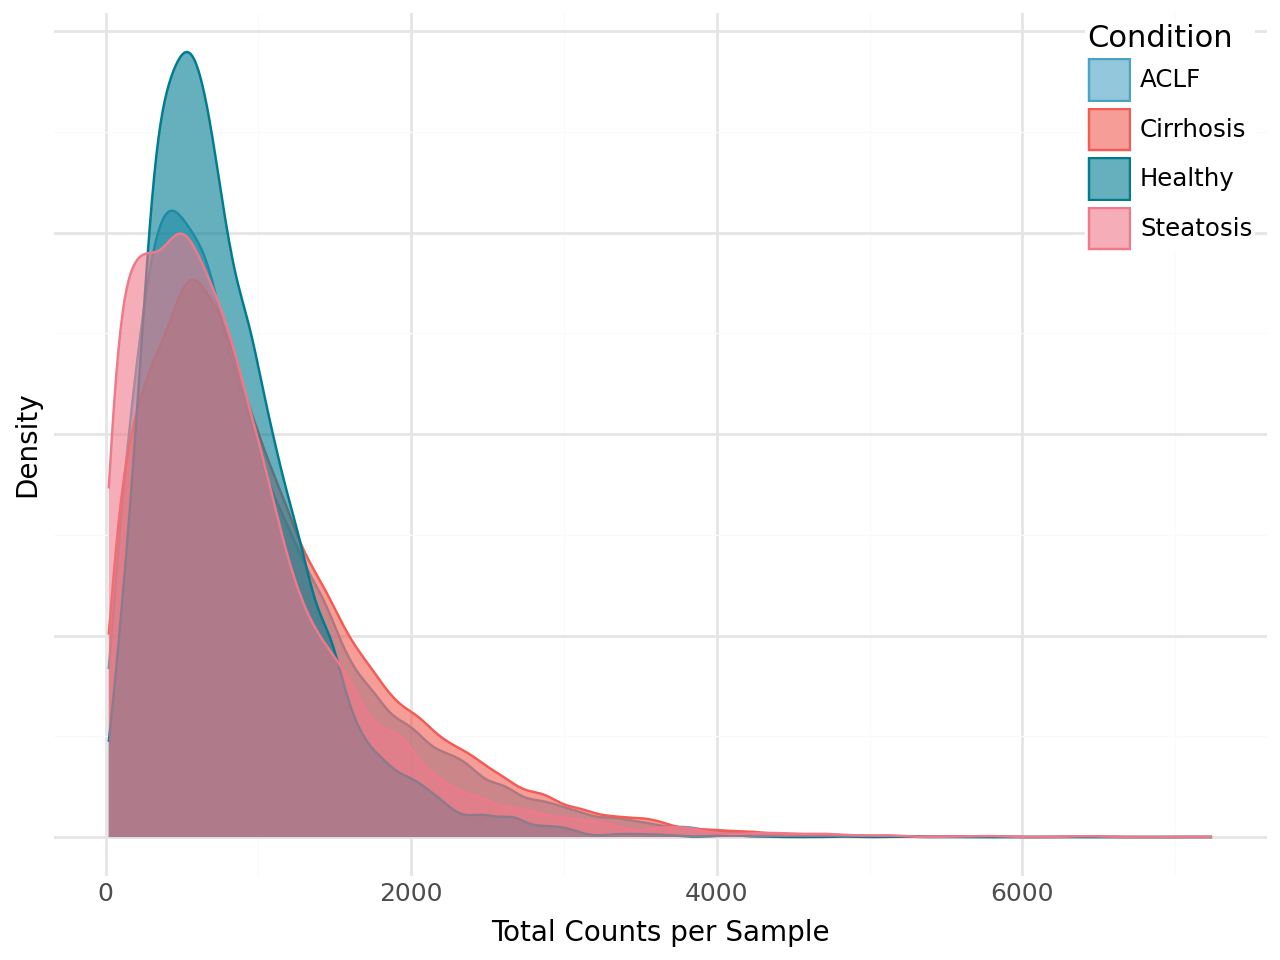

In [11]:
plot = (
    ggplot(data, aes(x="value", color="disease_state", fill="disease_state"))
    + geom_density(alpha=0.6)
    + scale_color_manual(custom_colors[2:6])
    + scale_fill_manual(custom_colors[2:6])
    + labs(
        x="Total Counts per Sample",
        y="Density",
        color="Condition",
        fill="Condition",
    )
    + figure_theme
    + theme(
        legend_position=(0.99, 0.99),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
        axis_text_y=element_blank(),
    )
)

plot.save("output/parts/density_condition_counts.svg", dpi=300)
plot

In [12]:
# Load gene count distribution
data = pd.read_feather("data/pdata_counts_per_gene.feather")

data = data.rename(columns={"value": "log10p1"})
data["dataset"] = data["dataset"].replace({"liver1": "Liver1", "liver2": "Liver2"})

data.head()

,raw_counts,dataset,log10p1
0,9926.0,Liver1,3.996818
1,23954.0,Liver1,4.379396
2,4548.0,Liver1,3.657916
3,8327.0,Liver1,3.920541
4,2801.0,Liver1,3.447468


/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/density_gene_counts.svg


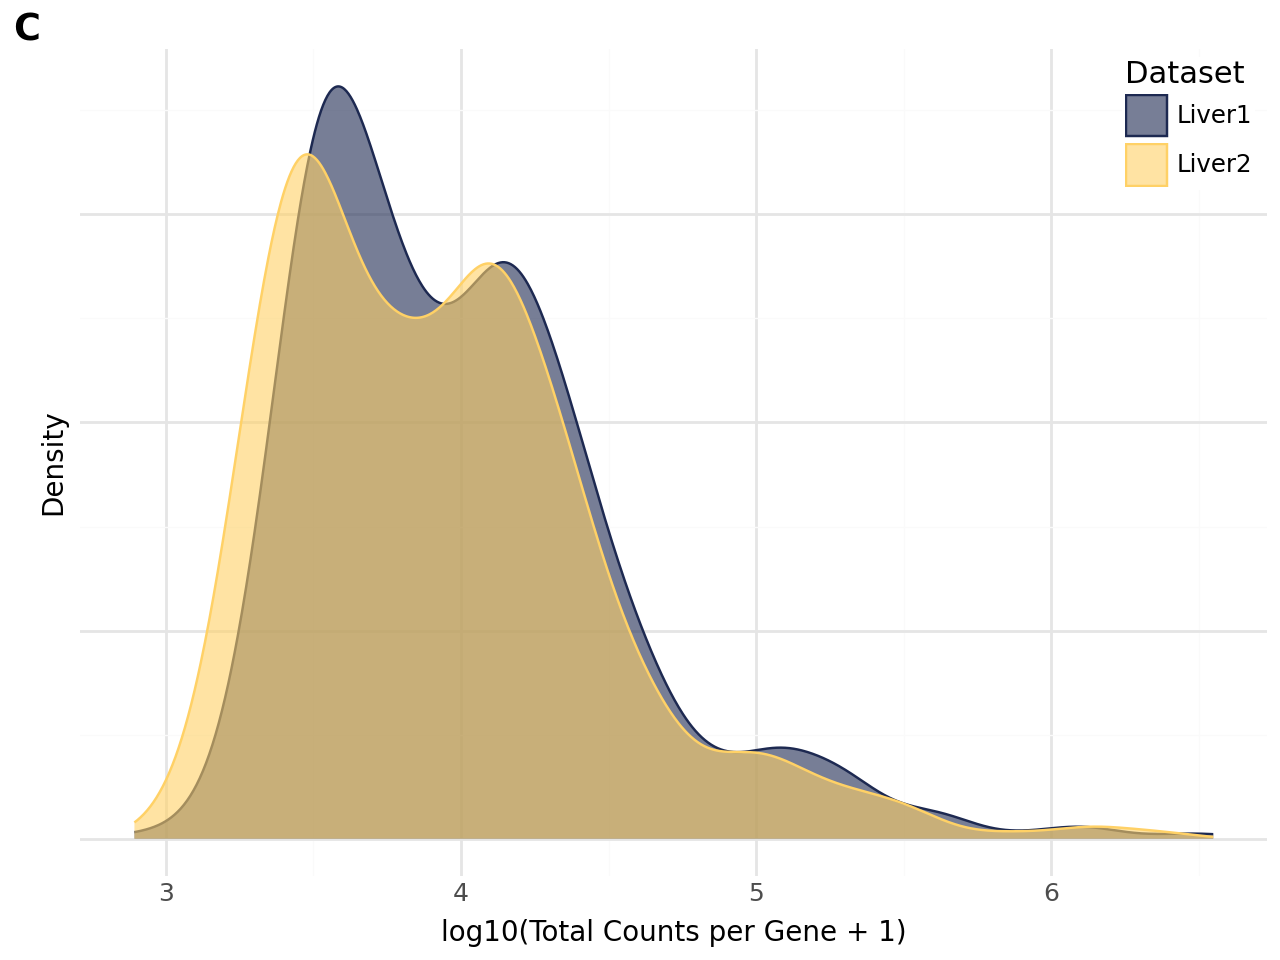

In [13]:
plot = (
    ggplot(data, aes(x="log10p1", color="dataset", fill="dataset"))
    + geom_density(alpha=0.6)
    + scale_color_manual(custom_colors[:2])
    + scale_fill_manual(custom_colors[:2])
    + labs(
        tag="C",
        x="log10(Total Counts per Gene + 1)",
        y="Density",
        color="Dataset",
        fill="Dataset",
    )
    + figure_theme
    + theme(
        axis_text_y=element_blank(),
        legend_position=(0.99, 0.99),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/density_gene_counts.svg", dpi=300)
plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/parts/ecdf_gene_counts.svg


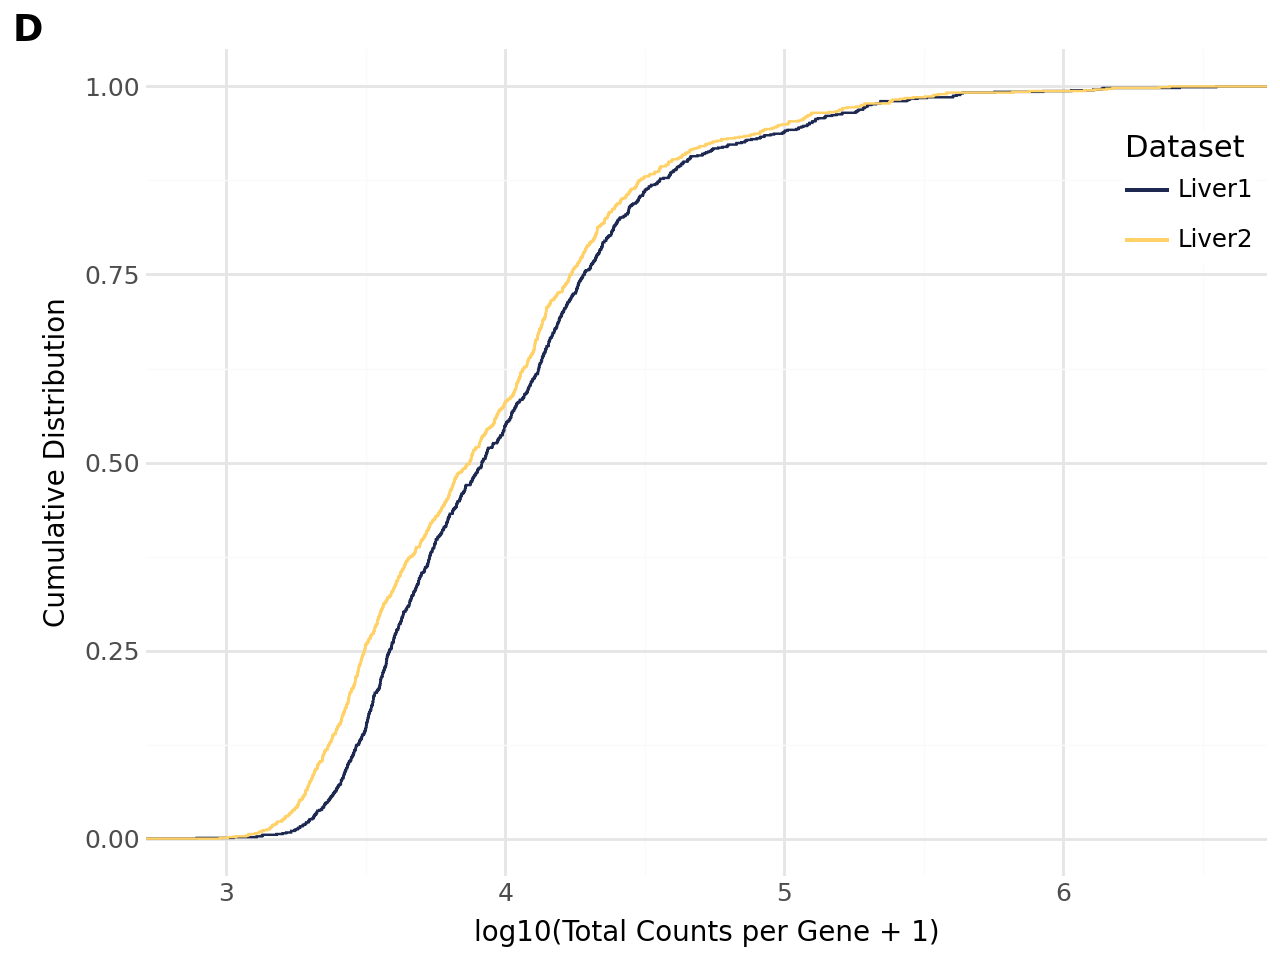

In [14]:
plot = (
    ggplot(data, aes(x="log10p1", color="dataset"))
    + stat_ecdf(geom="step")
    + scale_color_manual(custom_colors[:2])
    + labs(
        tag="D",
        x="log10(Total Counts per Gene + 1)",
        y="Cumulative Distribution",
        color="Dataset",
    )
    + figure_theme
    + theme(
        legend_position=(0.99, 0.90),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/ecdf_gene_counts.svg", dpi=300)
plot

## Count Distributions With Training Data

In [15]:
train_sample_counts = pd.read_feather("data/pdata_train_sample_counts.feather")
train_sample_counts = train_sample_counts.rename(
    columns={"Dataset": "dataset", "counts": "value"}
)
train_sample_counts.head()

,value,dataset
AAACCTGAGAGCCCAA-1,2293,Healthy
AAACCTGAGCTAGTCT-1,2066,Healthy
AAACCTGAGTTCGCGC-1,1013,Healthy
AAACCTGCAACACCCG-1,2209,Healthy
AAACCTGCATAGGATA-1,5290,Healthy


In [ ]:
st_sample_counts = pd.read_feather("data/pdata_counts_per_cell.feather")

st_sample_counts = st_sample_counts[["value", "dataset"]]
st_sample_counts["dataset"] = st_sample_counts["dataset"].replace(
    {
        "liver1": "Liver1",
        "liver2": "Liver2",
    }
)

st_sample_counts.head()

,value,dataset
0,450.0,Liver1
1,780.0,Liver1
2,752.0,Liver1
3,725.0,Liver1
4,395.0,Liver1


In [ ]:
data = pd.concat([st_sample_counts, train_sample_counts], ignore_index=True)

data["dataset"] = pd.Categorical(
    data["dataset"],
    categories=[
        "Liver1",
        "Liver2",
        "Healthy",
        "NAFLD",
    ],
    ordered=True,
)

data.dataset.unique()

['Liver1', 'Liver2', 'Healthy', 'NAFLD']
Categories (4, object): ['Liver1' < 'Liver2' < 'Healthy' < 'NAFLD']

In [20]:
data["value_z"] = data.groupby("dataset", observed=True)["value"].transform(
    lambda x: (x - x.mean()) / x.std()
)
data.head()

,value,dataset,value_z
0,450.0,Liver1,-0.743173
1,780.0,Liver1,-0.300586
2,752.0,Liver1,-0.338138
3,725.0,Liver1,-0.374350
4,395.0,Liver1,-0.816938


In [ ]:
plot = (
    ggplot(data, aes(x="dataset", y="value_z", fill="dataset"))
    + geom_violin(position="dodge", alpha=0.9, raster=True)
    + geom_boxplot(width=0.1, fill="#ffffff")
    + scale_fill_manual(values=custom_colors[:4])
    + labs(x="Dataset", y="Total Counts per Sample", fill="Dataset")
    + figure_theme
    + theme(
        legend_position=(0.99, 0.99),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/violin_sample_counts_all.svg", dpi=300)
plot

In [ ]:
train_gene_counts = pd.read_feather("data/pdata_train_gene_counts.feather")

train_gene_counts = train_gene_counts.rename(
    columns={
        "Dataset": "dataset",
        "counts": "value",
    }
)

train_gene_counts.head()

,value,dataset
Xkr4,3.368101,Healthy
Gm1992,1.342423,Healthy
Gm37381,1.113943,Healthy
Rp1,2.431364,Healthy
Sox17,4.504158,Healthy


In [11]:
# Load gene count distribution
st_gene_counts = pd.read_feather("data/pdata_counts_per_gene.feather")

st_gene_counts = st_gene_counts[["dataset", "value"]]
st_gene_counts["dataset"] = st_gene_counts["dataset"].replace(
    {
        "liver1": "Liver1",
        "liver2": "Liver2",
    }
)


st_gene_counts.head()

,dataset,value
0,Liver1,3.996818
1,Liver1,4.379396
2,Liver1,3.657916
3,Liver1,3.920541
4,Liver1,3.447468


In [13]:
data = pd.concat([st_gene_counts, train_gene_counts], ignore_index=True)

data["dataset"] = pd.Categorical(
    data["dataset"],
    categories=[
        "Liver1",
        "Liver2",
        "Healthy",
        "NAFLD",
    ],
    ordered=True,
)

data.dataset.unique()

['Liver1', 'Liver2', 'Healthy', 'NAFLD']
Categories (4, object): ['Liver1' < 'Liver2' < 'Healthy' < 'NAFLD']

In [ ]:
plot = (
    ggplot(data, aes(x="dataset", y="value", fill="dataset"))
    + geom_violin(position="dodge", alpha=0.9, raster=True)
    + geom_boxplot(width=0.1, fill="#ffffff")
    + scale_fill_manual(values=custom_colors[:4])
    + labs(x="Dataset", y="Total Counts per Gene", fill="Dataset")
    + figure_theme
    + theme(
        legend_position=(0.99, 0.99),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/violin_sample_counts_all.svg", dpi=300)
plot

## UMAPs Before Integration

In [ ]:
# Add original cell types to plot data
ct_anno = pd.read_feather("data/pdata_original_cell_types.feather")
ct_anno = ct_anno.set_index("id")["nb_clus"]
ct_anno

In [ ]:
data = pd.read_feather("data/pdata_umaps_ST.feather")

data["original_ct"] = ct_anno
data["fov"] = pd.Categorical(data["fov"])
data["condition"] = data["condition"].map(
    {
        "healthy": "Healthy",
        "steatosis": "Steatosis",
        "cirrhosis": "Cirrhosis",
        "aclf": "ACLF",
    }
)

data

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="slide"))
    + geom_point(
        alpha=0.8,
        size=1,
        stroke=0,
        raster=True,  # Raster to decrease figure size
    )
    + scale_fill_manual(values=custom_colors[:2])
    + labs(tag="A", x="UMAP1", y="UMAP2", fill="Slide")
    + guides(fill=guide_legend(override_aes={"size": 4}))
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position=(0.5, 1),
        legend_justification=(0.5, 0),
        legend_direction="horizontal",
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/initial_umap_slide.svg", dpi=300)
plot

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="condition"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + scale_fill_manual(values=custom_colors[:4])
    + labs(tag="B", x="UMAP1", y="UMAP2", fill="Condition")
    + guides(fill=guide_legend(override_aes={"size": 4}))
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position=(0.5, 1),
        legend_justification=(0.5, 0),
        legend_direction="horizontal",
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/initial_umap_condition.svg", dpi=300)
plot

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="fov"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + labs(tag="C", x="UMAP1", y="UMAP2")
    + scale_fill_manual(custom_colors_xl[: data["fov"].nunique()])
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position="none",
    )
)

plot.save("output/parts/initial_umap_fov.svg", dpi=300)
plot

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="original_ct"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + labs(tag="D", x="UMAP1", y="UMAP2", fill="Cell Type")
    + scale_fill_manual(custom_colors_xl[: data["original_ct"].nunique()])
    + guides(fill=guide_legend(ncol=1, override_aes={"size": 4}))
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

plot.save("output/parts/initial_umap_cell_type.svg", dpi=300)
plot

## Integrated UMAPs

In [ ]:
data = pd.read_feather("data/pdata_latent_umaps.feather")

data["condition"] = data["condition"].map(
    {
        "healthy": "Healthy",
        "steatosis": "Steatosis",
        "cirrhosis": "Cirrhosis",
        "aclf": "ACLF",
    }
)

data.head()

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="slide"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + scale_fill_manual(values=custom_colors[:2])
    + labs(tag="A", x="UMAP1", y="UMAP2", fill="Slide")
    + guides(fill=guide_legend(override_aes={"size": 4}))
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position=(0.5, 1),
        legend_justification=(0.5, 0),
        legend_direction="horizontal",
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/latent_umap_slide.svg", dpi=300)
plot

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="condition"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + scale_fill_manual(values=custom_colors[:4])
    + labs(tag="B", x="UMAP1", y="UMAP2", fill="Condition")
    + guides(fill=guide_legend(override_aes={"size": 4}))
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position=(0.5, 1),
        legend_justification=(0.5, 0),
        legend_direction="horizontal",
        legend_background=element_rect(fill="white", color="none"),
    )
)

plot.save("output/parts/latent_umap_condition.svg", dpi=300)
plot

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="fov"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + labs(tag="C", x="UMAP1", y="UMAP2")
    + scale_fill_manual(custom_colors_xl[: data["fov"].nunique()])
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position="none",
    )
)

plot.save("output/parts/latent_umap_fov.svg", dpi=300)
plot

In [ ]:
label_positions = (
    data.groupby("cluster", observed=True)[["umap_1", "umap_2"]].median().reset_index()
)

label_positions.head()

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="cluster"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + geom_text(
        label_positions,
        aes("umap_1", "umap_2", label="cluster"),
        size=8,
        fontweight="bold",
        color="black",
    )
    + scale_fill_manual(values=custom_colors[: data["cluster"].nunique()])
    + labs(tag="D", x="UMAP1", y="UMAP2")
    + guides(fill="none")
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

plot.save("output/parts/latent_umap_cluster.svg", dpi=300)
plot

In [ ]:
data = pd.read_feather("data/pdata_normalized_umaps.feather")
data.head()

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2"))
    + geom_point(fill="#1D2951", alpha=0.8, size=1, stroke=0, raster=True)
    + labs(tag="A", x="UMAP1", y="UMAP2")
    + guides(fill="none")
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

plot.save("output/parts/normalized_umap.svg", dpi=300)
plot

In [ ]:
label_positions = (
    data.groupby("cluster", observed=True)[["umap_1", "umap_2"]].median().reset_index()
)

label_positions.head()

In [ ]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="cluster"))
    + geom_point(alpha=0.8, size=1, stroke=0, raster=True)
    + geom_text(
        label_positions,
        aes("umap_1", "umap_2", label="cluster"),
        size=8,
        fontweight="bold",
        color="black",
    )
    + scale_fill_manual(values=custom_colors_xl[: data["cluster"].nunique()])
    + labs(tag="B", x="UMAP1", y="UMAP2")
    + guides(fill="none")
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

plot.save("output/parts/normalized_umap_cluster.svg", dpi=300)
plot

## Cell Type Distribution (scRNA-seq Data)

In [6]:
cell_types = pd.read_feather("data/pdata_cell_types.feather")

# Rename column to make it more readable
cell_types["annotation"] = cell_types["annotation"].replace(
    {"Monocytes & Monocyte-derived cells": "Monocytes &\nMonocyte-derived cells"}
)
cell_types.head()

,Dataset,annotation,count,percentage
0,Healthy,Endothelial cells,50194,27.001409
1,Healthy,Kupffer cells,39311,21.146998
2,Healthy,Hepatocytes,25908,13.936975
3,Healthy,Monocytes &\nMonocyte-derived cells,20712,11.141834
4,Healthy,T cells,9912,5.332071


/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: output/train_cell_types.svg


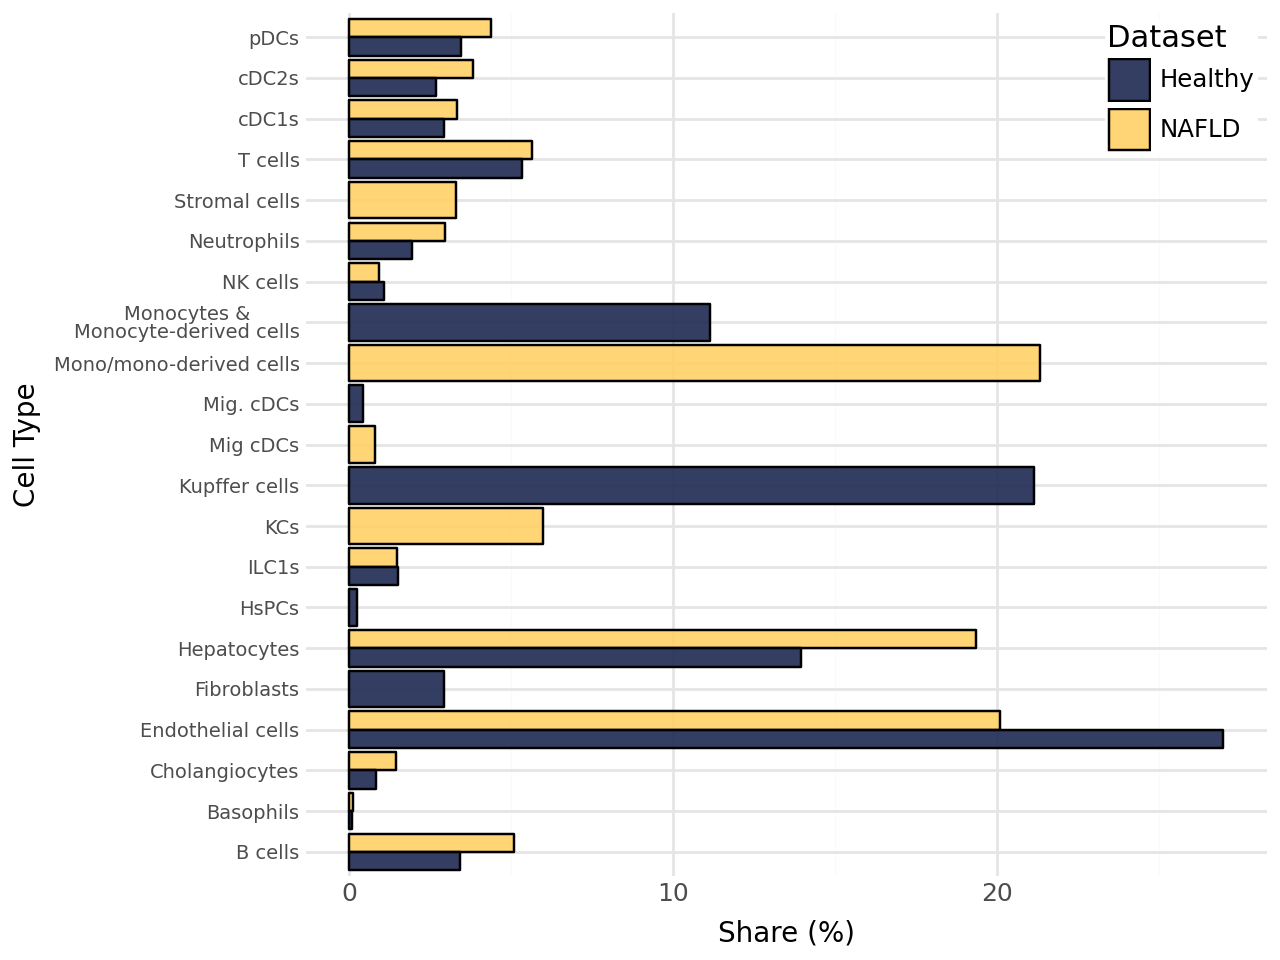

In [8]:
plot = (
    ggplot(cell_types, aes(x="annotation", y="percentage", fill="Dataset"))
    + geom_col(position="dodge", alpha=0.9, color="black")
    + coord_flip()
    + scale_fill_manual(values=["#1D2951", "#FFD166"])
    + labs(x="Cell Type", y="Share (%)")
    + figure_theme
    + theme(
        legend_position=(0.99, 0.99),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
        axis_text_y=element_text(size=7),
    )
)

plot.save("output/train_cell_types.svg", dpi=300)
plot